# Macro Regime × Event Risk Monitor for Electronic Market Makers
### FINM 35900 · Virtu Financial · Antonio, Beckham, Christo, Kevin

## The improvement we are making

Virtu Financial makes money by quoting buy and sell prices on thousands of stocks and capturing the spread. Their main risk is getting caught holding inventory at the wrong moment, like during a CPI surprise that gaps the market down 2 percent in five minutes.

There are two reasons markets move in stressful ways:

1. **The background macro environment.** Some weeks the market is calm. Other weeks investors are nervous, inflation is uncertain, or credit conditions are tightening. A quiet Tuesday in a nervous week tends to move more than a quiet Tuesday in a calm week, even with no news.

2. **Scheduled releases.** CPI prints, FOMC announcements, jobs reports, and others land at predictable times and reliably move prices. These are the appointment risks.

Public research on macro risk for market makers usually focuses on one channel or the other. Event studies analyze what happens around CPI prints. Regime studies analyze what happens during nervous versus calm periods. Almost nobody publicly combines them, even though the combination is what actually matters. An FOMC announcement during a tense market is far riskier than the same announcement during a calm one.

Virtu's internal risk team almost certainly already knows this and acts on it. What they do not have publicly, and what no external observer currently provides, is a transparent reproducible version of the same logic. Our framework gives the firm one in three concrete ways:

1. **Explaining quarterly results to investors.** When Virtu reports a big revenue quarter, investors guess whether it was firm skill or just a stressful macro calendar. A public framework that explains a measurable share of Virtu's revenue lets management cleanly say "this much of the quarter was macro, this much was us."

2. **Benchmarking their internal models.** Risk committees and external auditors need an independent reference. If Virtu's internal model says today is low risk but a public framework disagrees, that is a useful signal worth investigating.

3. **Taking a public position on the May 15, 2026 Fed Chair handover.** Powell will remain on the Fed Board as a regular governor after losing the Chair job. Markets have never priced an FOMC decision with the former Chair still in the room. Virtu will be asked by analysts and reporters what they expect. A public framework gives them a defensible answer.

## The one-sentence thesis

In nervous macro periods, options are systematically priced too cheaply relative to what actually happens, and the worst losses come from bigger-than-expected drops. Within those periods, scheduled events like CPI and FOMC drive most of the realized stress. The right risk decision for a market maker depends on both at once: what kind of macro week we are in, and what events are coming.

## Approach: transparent rule-based regimes and pre-registered tests

Every regime is defined by explicit, economically meaningful thresholds derived from causal expanding percentiles, with no look-ahead and no black-box clustering. Every Virtu validation hypothesis is pre-registered with predicted signs and minimum correlation thresholds before the data is examined, so the test is falsifiable rather than data-mined. The deliverable is a 4 × 5 risk monitor grid (4 regimes by 5 event types, each cell classified into one of 3 tiers) that a market maker can defend in front of investors, regulators, or an internal risk committee.

## Notebook map → slides

| # | Section | Slide |
|---|---------|-------|
| 0 | Setup | — |
| 1 | Load and inspect all data | 1–2 (data) |
| 2 | Define regimes with explicit rules | 3 (method) |
| 3 | Regime timeline and frequency | 3 (method) |
| 4 | VRP per regime, when options are systematically underpriced | 4 (result 1) |
| 5 | Fat tails per regime (SCOFT / Taleb) | 5a (result 2) |
| 6.1 | Event panel construction | — |
| 6.2 | Per-event composite stress score | — |
| 6.3 | **Event stress conditional on regime** (the merge novelty) | 5b (result 2) |
| 7 | Pre-registered Virtu validation | 6 (result 3) |
| 8 | 4 × 5 regime × event risk monitor | 7 (conclusion) |
| 9 | 2026 Fed Chair transition application | 7 (conclusion) |


## 0 · Setup

In [1]:
# !pip install pandas numpy matplotlib pyarrow scipy
# Warnings are intentionally NOT silenced: a suppressed pct_change FutureWarning is exactly what
# hid the upstream CPI-YoY scaling bug. Keep them visible.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
PALETTE = {"Calm": "#4C9F70", "Inflationary": "#E1A730",
           "Tightening-stress": "#C44E52", "Crisis": "#7B2D26"}

DATA = Path("./data"); CLEAN, RAW = DATA/"clean", DATA/"raw"
FIG = Path("./figures"); FIG.mkdir(exist_ok=True)
for _stale in FIG.glob("*.png"):     # clear stale figures so the saved-figures list reflects THIS run
    _stale.unlink()

def load(rel):
    fp = DATA/rel
    assert fp.exists(), f"MISSING {fp} (run the data-collection notebook first)."
    return pd.read_parquet(fp)
print("ready")

ready


## 1 · Load and inspect every dataset

**What this section does.** Load every dataset we use downstream and confirm each one looks right (correct date range, no silent gaps, no obvious data errors).

**Why this matters.** Macro analysis is unforgiving of data issues. A CPI series scaled wrong by a factor of 100, or a VIX series with a six-month gap, will propagate quietly through every downstream result and corrupt the final monitor. The cells below produce four diagnostics: (1) an inventory table listing every dataset and its size, (2) a column-level coverage check, (3) a 4-panel plot of the main macro series with major stress dates marked, and (4) a return distribution check that confirms returns are fat-tailed (which justifies the Hill α analysis in Section 5).

In [2]:
# Load everything saved by the collection notebook
panel    = load("clean/master_daily_panel.parquet")
derived  = load("clean/derived_vol_series.parquet")
fund_q   = load("raw/virt_fundamentals_q.parquet")
calendar = load("raw/release_calendar.parquet")
virt     = load("raw/virt_daily.parquet")

# Additional loads for the event-layer analysis (Section 5.5 onward).
# macro_surprises has random-walk surprises (actual minus prior) for CPI / Core PCE / NFP / IndPro.
# quarterly_virtu_macro is Virtu fundamentals already aligned with mkt_vol_q and the regime stress share.
surprises      = load("clean/macro_surprises.parquet")
virt_q_aligned = load("clean/quarterly_virtu_macro.parquet")

# Drop dead columns: only 2006-2008 coverage (~3-4%) and unused downstream.
panel = panel.drop(columns=[c for c in ["volvol_realized_1m", "ust10_yieldvol"] if c in panel.columns])

datasets = {
    "master panel (daily)":                       panel,
    "derived vol series (VRP, RV, IV, vol-of-vol)": derived,
    "Virtu fundamentals (Q)":                     fund_q,
    "release calendar (event dates)":             calendar,
    "Virtu daily prices":                         virt,
    "macro surprises (random-walk based)":        surprises,
    "Virtu quarterly aligned":                    virt_q_aligned,
}
rows = []
for name, df in datasets.items():
    idx = df.index if isinstance(df.index, pd.DatetimeIndex) else None
    span = (f"{idx.min().date()} -> {idx.max().date()}" if idx is not None
            else f"{df['date'].min().date()} -> {df['date'].max().date()}" if 'date' in df else "n/a")
    rows.append({"dataset": name, "rows": len(df), "cols": df.shape[1], "date span": span})
print("DATA INVENTORY")
print(pd.DataFrame(rows).to_string(index=False))

print("\nEVENT TYPES IN RELEASE CALENDAR (used in Section 5.5 onward)")
print(calendar["event"].value_counts().to_string())


DATA INVENTORY
                                     dataset  rows  cols                date span
                        master panel (daily)  5218    25 2006-01-02 -> 2025-12-31
derived vol series (VRP, RV, IV, vol-of-vol)  7007     8 2006-01-01 -> 2025-12-31
                      Virtu fundamentals (Q)    52    14                      n/a
              release calendar (event dates)  1243     3 2006-01-06 -> 2025-12-23
                          Virtu daily prices  2695     7 2015-04-16 -> 2025-12-31
         macro surprises (random-walk based)  7007     8 2006-01-01 -> 2025-12-31
                     Virtu quarterly aligned    49     5 2013-12-31 -> 2025-12-31

EVENT TYPES IN RELEASE CALENDAR (used in Section 5.5 onward)
event
CPI                 239
Unemployment        238
Nonfarm Payrolls    238
GDP                 236
Core PCE            236
FOMC                 56


In [3]:
# Coverage check on the panel: how complete is each column? (catches silent gaps)
cov = pd.DataFrame({
    "non_null": panel.notna().sum(),
    "coverage_%": (panel.notna().mean()*100).round(1),
    "first_valid": panel.apply(lambda s: s.first_valid_index()),
    "last_valid": panel.apply(lambda s: s.last_valid_index()),
})
print("PANEL COLUMN COVERAGE")
display(cov)
print("\nNote: vrp_1m / rv_minus_iv_1m are blank for the final ~21 days BY DESIGN")
print("(they use the next 21 days of realized vol — the future isn't available yet).")

PANEL COLUMN COVERAGE


,non_null,coverage_%,first_valid,last_valid
vix,5058,96.9,2006-01-03,2025-12-31
rvol_trail_1m,4761,91.2,2006-02-01,2024-12-31
rv_minus_iv_1m,4760,91.2,2006-01-03,2024-11-29
vrp_1m,4760,91.2,2006-01-03,2024-11-29
vix_term,4548,87.2,2007-12-04,2025-12-31
dgs10,5003,95.9,2006-01-03,2025-12-31
dgs2,5003,95.9,2006-01-03,2025-12-31
dgs3mo,5003,95.9,2006-01-03,2025-12-31
t10y2y,5003,95.9,2006-01-03,2025-12-31
fedfunds_upper,4447,85.2,2008-12-16,2025-12-31



Note: vrp_1m / rv_minus_iv_1m are blank for the final ~21 days BY DESIGN
(they use the next 21 days of realized vol — the future isn't available yet).


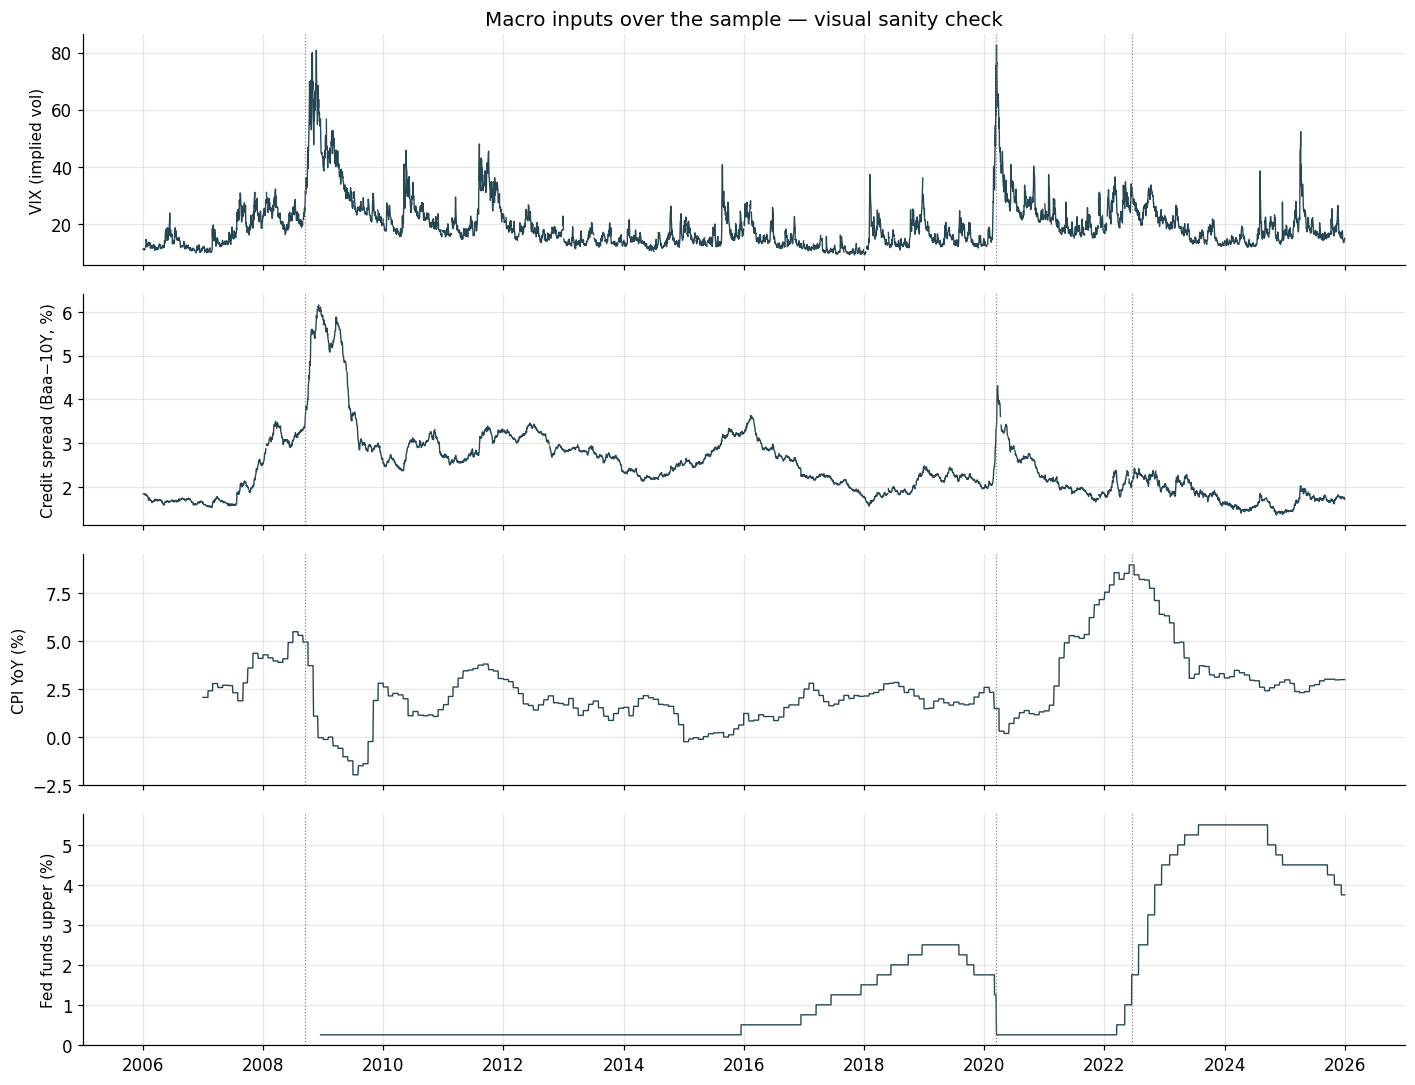

In [4]:
# Sanity plot: the four key macro series over time, with the big stress episodes marked.
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
series = [("vix", "VIX (implied vol)"), ("credit_spread", "Credit spread (Baa−10Y, %)"),
          ("cpi_yoy", "CPI YoY (%)"), ("fedfunds_upper", "Fed funds upper (%)")]
events = {"GFC 2008": "2008-09-15", "COVID 2020": "2020-03-16", "2022 hikes": "2022-06-15"}
for ax, (col, lab) in zip(axes, series):
    if col in panel:
        ax.plot(panel.index, panel[col], lw=0.9, color="#264653")
        ax.set_ylabel(lab, fontsize=10)
        for nm, dt in events.items():
            ax.axvline(pd.Timestamp(dt), color="grey", ls=":", lw=0.8)
axes[0].set_title("Macro inputs over the sample — visual sanity check", fontsize=13)
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout(); plt.savefig(FIG/"01_data_overview.png", bbox_inches="tight"); plt.show()

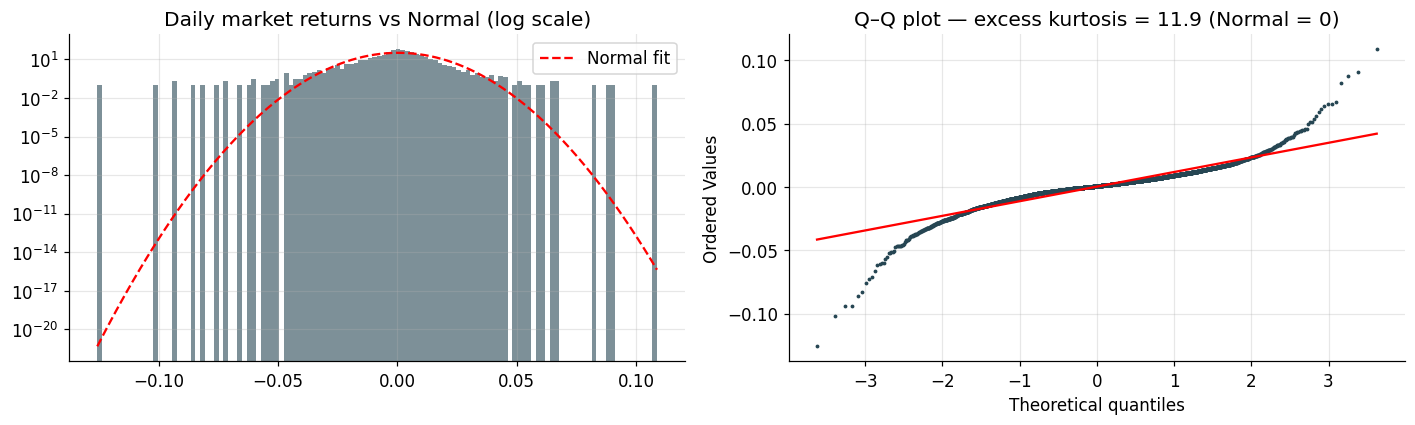

Excess kurtosis 11.9, min day -12.6%, max day 10.9%
=> returns are clearly fat-tailed; this is WHY the SCOFT tail analysis matters (Section 5).


In [5]:
# Look at the return distribution we'll be doing tail analysis on — is it actually fat-tailed?
r = derived["mkt_logret"].dropna()
from scipy import stats
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.hist(r, bins=120, density=True, alpha=0.6, color="#264653")
x = np.linspace(r.min(), r.max(), 300)
a1.plot(x, stats.norm.pdf(x, r.mean(), r.std()), "r--", lw=1.5, label="Normal fit")
a1.set_yscale("log"); a1.set_title("Daily market returns vs Normal (log scale)"); a1.legend()
stats.probplot(r, dist="norm", plot=a2)
a2.set_title(f"Q–Q plot — excess kurtosis = {r.kurtosis():.1f} (Normal = 0)")
a2.get_lines()[0].set(marker=".", markersize=3, color="#264653"); a2.get_lines()[1].set(color="r")
plt.tight_layout(); plt.savefig(FIG/"01_returns_fattail.png", bbox_inches="tight"); plt.show()
print(f"Excess kurtosis {r.kurtosis():.1f}, min day {r.min()*100:.1f}%, max day {r.max()*100:.1f}%")
print("=> returns are clearly fat-tailed; this is WHY the SCOFT tail analysis matters (Section 5).")

## 2 · Define the regimes - explicit rules

**What this section does.** Attach a regime label to every trading day from 2006 to 2025. There are four possible labels: **Calm**, **Inflationary**, **Tightening-stress**, **Crisis**. The label summarizes the macro backdrop on that day in one word.

**Why this matters.** The regime classification is Layer 1 of the framework. Every downstream section depends on it: VRP analysis (Section 4), fat-tail analysis (Section 5), event × regime grid (Section 6.3), Virtu validation (Section 7), and the final risk monitor (Section 8). Without these labels, we cannot ask "how stressful is today's macro environment."

**How the labels are assigned.** Each regime is defined by explicit, economically meaningful thresholds on contemporaneous variables (VIX level, credit spread, CPI YoY, financial conditions). Thresholds are **causal expanding percentiles**: on each day the cutoff uses only the history available up to that day, with a 3-year warm-up seed. This removes look-ahead bias. A real-time monitor running in 2010 could reproduce its own 2010 labels.

When multiple thresholds are exceeded, the severity order wins: Crisis > Tightening-stress > Inflationary > Calm. A minimum-run rule (10 trading days) prevents the classifier from flickering between regimes for noise reasons.

In [6]:
# Causal percentile thresholds: at each date the cutoffs use only history available UP TO that day
# (expanding window), with a 3-year seed so 2006-2008 isn't classified off a handful of obs. This
# removes the look-ahead of full-sample percentiles: a monitor running in 2010 could reproduce its
# own 2010 thresholds in real time.
SEED = 756  # ~3 trading years

def causal_thr(s, q):
    s = s.astype(float)
    seed = s.iloc[:SEED].quantile(q)                       # constant warm-up cutoff for the first ~3y
    return s.expanding(min_periods=SEED).quantile(q).fillna(seed)

TH = pd.DataFrame(index=panel.index)
TH["vix_hi"]  = causal_thr(panel["vix"], 0.80)             # acute implied-vol stress
TH["vix_mid"] = causal_thr(panel["vix"], 0.60)
TH["cr_hi"]   = causal_thr(panel["credit_spread"], 0.75)   # credit stress
TH["cpi_hi"]  = causal_thr(panel["cpi_yoy"], 0.70)         # elevated inflation
TH["nfci_hi"] = causal_thr(panel["nfci"], 0.70) if "nfci" in panel else np.inf  # tight fin. conditions

last = TH.iloc[-1]
print("REGIME THRESHOLDS - causal expanding percentiles (3y warm-up); latest values:")
print(f"  VIX  : elevated > {last.vix_hi:.1f} (80th pct), moderate > {last.vix_mid:.1f} (60th)")
print(f"  Credit spread tight > {last.cr_hi:.2f}% (75th pct)")
print(f"  CPI YoY elevated > {last.cpi_hi:.1f}% (70th pct)")
print(f"  NFCI tight > {last.nfci_hi:.2f} (70th pct)")

# Assign in increasing severity so the most severe matching rule wins:
# Crisis > Tightening-stress > Inflationary > Calm. NaN comparisons are False, so missing inputs
# simply fail to trigger a regime (the day stays Calm), matching the original elif chain.
vix  = panel["vix"]
cr   = panel["credit_spread"] if "credit_spread" in panel else pd.Series(np.nan, index=panel.index)
cpi  = panel["cpi_yoy"]       if "cpi_yoy"       in panel else pd.Series(np.nan, index=panel.index)
nfci = panel["nfci"]          if "nfci"          in panel else pd.Series(np.nan, index=panel.index)

regime = pd.Series("Calm", index=panel.index, name="regime")
regime[cpi >= TH["cpi_hi"]]  = "Inflationary"                 # high inflation, calm-ish vol
regime[vix >= TH["vix_mid"]] = "Tightening-stress"            # elevated vol
regime[(vix >= TH["vix_hi"]) & ((cr >= TH["cr_hi"]) | (nfci >= TH["nfci_hi"]))] = "Crisis"  # acute vol + credit/FCI stress

panel = panel.assign(regime=regime)
print("\nREGIME FREQUENCY (raw, pre-smoothing):")
display(regime.value_counts().to_frame("days").assign(
    pct=lambda d: (d["days"]/d["days"].sum()*100).round(1)))

REGIME THRESHOLDS - causal expanding percentiles (3y warm-up); latest values:
  VIX  : elevated > 24.0 (80th pct), moderate > 18.8 (60th)
  Credit spread tight > 2.87% (75th pct)
  CPI YoY elevated > 2.9% (70th pct)
  NFCI tight > -0.35 (70th pct)

REGIME FREQUENCY (raw, pre-smoothing):


,days,pct
regime,,
Calm,2499,47.9
Tightening-stress,1247,23.9
Inflationary,979,18.8
Crisis,493,9.4


In [7]:
# Enforce a minimum regime duration: any run shorter than MIN_RUN days gets absorbed
# into the regime that precedes it. Economically: you don't switch risk posture for a blip.
MIN_RUN = 10  # trading days (~2 weeks)

r = panel["regime"].copy()
# identify runs
grp = (r != r.shift()).cumsum()
run_len = r.groupby(grp).transform("size")
# walk forward, replacing too-short runs with the last "confirmed" regime
confirmed = r.copy()
last_good = r.iloc[0]
for g, sub in r.groupby(grp):
    if len(sub) >= MIN_RUN:
        last_good = sub.iloc[0]
    else:
        confirmed.loc[sub.index] = last_good
panel["regime"] = confirmed

print(f"After enforcing min run = {MIN_RUN} days:")
display(panel["regime"].value_counts().to_frame("days").assign(
    pct=lambda d: (d["days"]/d["days"].sum()*100).round(1)))

After enforcing min run = 10 days:


,days,pct
regime,,
Calm,2543,48.7
Tightening-stress,1215,23.3
Inflationary,1004,19.2
Crisis,456,8.7


## 3 · Regime timeline - does it pass the eye test?

**What this section does.** Plot the regime labels as a shaded timeline overlaid on VIX history.

**Why this matters.** A regime classifier that doesn't visually align with the dates everyone agrees were stressed cannot be trusted on ambiguous periods. The chart below should mark 2008-2009, March 2020, and 2022 as stressed regimes. If it does not, the rules need revision before we use the labels downstream.

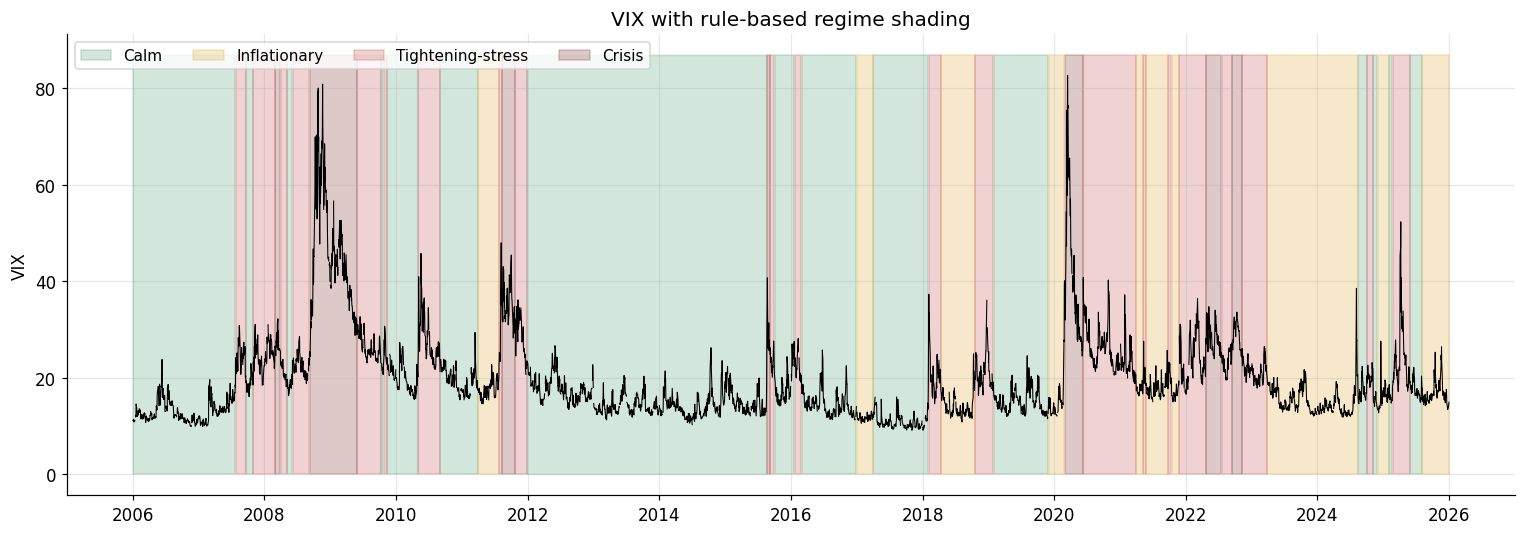

GFC (Oct 2008): {'Crisis': 0.93, 'Tightening-stress': 0.07}
COVID (Mar 2020): {'Crisis': 1.0}
2022 hikes: {'Crisis': 0.63, 'Tightening-stress': 0.37}


In [8]:
ORDER = ["Calm", "Inflationary", "Tightening-stress", "Crisis"]
fig, ax = plt.subplots(figsize=(14, 5))
vix = panel["vix"]
for r_ in ORDER:
    m = panel["regime"] == r_
    ax.fill_between(panel.index, 0, vix.max()*1.05, where=m, color=PALETTE[r_], alpha=0.25, label=r_)
ax.plot(vix.index, vix, color="black", lw=0.7)
ax.set_title("VIX with rule-based regime shading"); ax.set_ylabel("VIX")
ax.legend(loc="upper left", ncol=4, fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(2)); plt.tight_layout()
plt.savefig(FIG/"03_regime_timeline.png", bbox_inches="tight"); plt.show()

# Eye test: the famous stress windows should be Crisis/Tightening-stress
for nm, win in {"GFC (Oct 2008)": ("2008-09","2008-12"),
                "COVID (Mar 2020)": ("2020-03","2020-04"),
                "2022 hikes": ("2022-06","2022-10")}.items():
    s = panel.loc[win[0]:win[1], "regime"].value_counts(normalize=True).round(2)
    print(f"{nm}: {s.to_dict()}")

## 4 · Result 1 - VRP per regime: when are options systematically underpriced?

**What this section does.** For each regime, compute (1) how often realized volatility exceeded implied volatility over the next month, and (2) by how much in the tail (p95 and worst).

**Why this matters (in plain words).** The Variance Risk Premium (VRP) is the difference between what options charge for volatility (implied) and what actually happens (realized). When VRP is negative, options were too cheap. The buyer of options wins, the seller loses. For a market maker that sells gamma, persistent negative VRP means losses. This section asks: are some macro regimes systematically the ones where options are mispriced?

**One subtlety to note.** VRP looks 21 days forward (today's IV against the next month's realized vol). The worst underpricing day therefore often lands in a **Calm** regime that transitions into stress days later — the calm-before-the-storm effect. We report this explicitly in the diagnostic below.

**Two numbers per regime:**
- **share_IV_underpriced** = fraction of days with VRP < 0 (how *often* options are too cheap)
- **p95 / worst (realized minus implied)** = how *badly* realized overshoots implied in the tail

VARIANCE RISK PREMIUM BY REGIME  (regime today -> next-month VRP)


,days,avg_RV_minus_IV,p95_RV_minus_IV,worst_RV_minus_IV,share_IV_underpriced
regime,,,,,
Calm,2393,-3.414,4.672,16.689,0.168
Inflationary,819,-2.076,8.379,67.732,0.147
Tightening-stress,1107,-4.961,5.993,34.852,0.172
Crisis,441,-1.344,35.664,60.271,0.293



Worst forward-underpricing day per regime (calm-before-the-storm check):


,worst_date,worst_RV_minus_IV,regime_21d_later
regime,,,
Calm,2015-08-10,16.7,Crisis
Inflationary,2020-02-19,67.7,Crisis
Tightening-stress,2008-09-08,34.9,Crisis
Crisis,2020-03-04,60.3,Crisis


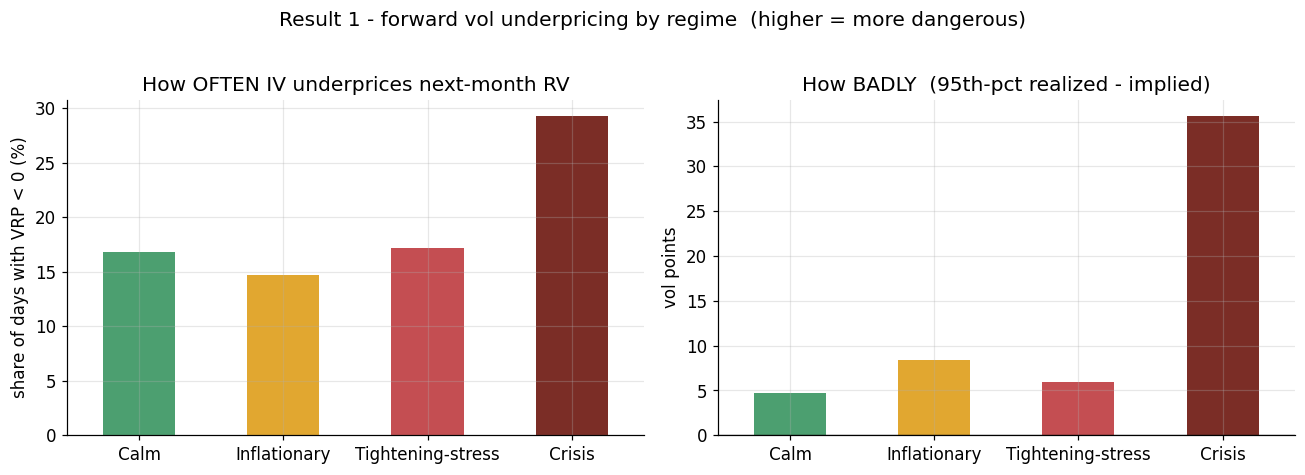

In [9]:
vrp = panel[["regime", "vrp_1m", "rv_minus_iv_1m"]].dropna()
res1 = vrp.groupby("regime").agg(
    days=("vrp_1m", "size"),
    avg_RV_minus_IV=("rv_minus_iv_1m", "mean"),
    p95_RV_minus_IV=("rv_minus_iv_1m", lambda s: s.quantile(0.95)),
    worst_RV_minus_IV=("rv_minus_iv_1m", "max"),
    share_IV_underpriced=("vrp_1m", lambda s: (s < 0).mean()),
).reindex(ORDER).round(3)
print("VARIANCE RISK PREMIUM BY REGIME  (regime today -> next-month VRP)")
display(res1)

# Transition check: the single worst forward-underpricing day per regime tends to be a CALM day
# right before stress erupts. Show its date and the regime ~21 trading days later.
HORIZON = 21
reg_future = panel["regime"].shift(-HORIZON)
worst = vrp.groupby("regime")["rv_minus_iv_1m"].idxmax()
worst = worst.reindex([r for r in ORDER if r in worst.index])
trans = pd.DataFrame({
    "worst_date": [d.date() for d in worst],
    "worst_RV_minus_IV": [round(vrp.at[d, "rv_minus_iv_1m"], 1) for d in worst],
    "regime_21d_later": [reg_future.get(d, "n/a") for d in worst],
}, index=worst.index)
print("\nWorst forward-underpricing day per regime (calm-before-the-storm check):")
display(trans)

# Two-part headline: how OFTEN options are too cheap (share) and how BADLY in the tail (p95).
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2))
(res1["share_IV_underpriced"] * 100).plot.bar(ax=axL, color=[PALETTE[r] for r in res1.index])
axL.set_title("How OFTEN IV underprices next-month RV"); axL.set_ylabel("share of days with VRP < 0 (%)")
axL.set_xlabel(""); axL.tick_params(axis="x", rotation=0)
res1["p95_RV_minus_IV"].plot.bar(ax=axR, color=[PALETTE[r] for r in res1.index])
axR.set_title("How BADLY  (95th-pct realized - implied)"); axR.set_ylabel("vol points")
axR.set_xlabel(""); axR.axhline(0, color="black", lw=0.8); axR.tick_params(axis="x", rotation=0)
fig.suptitle("Result 1 - forward vol underpricing by regime  (higher = more dangerous)", y=1.02)
plt.tight_layout(); plt.savefig(FIG/"04_vrp_by_regime.png", bbox_inches="tight"); plt.show()

## 5 · Result 2 - Fat tails per regime (SCOFT / Taleb)

**What this section does.** Measure the Hill tail exponent α for daily market returns within each regime, separately for the left tail (losses) and the right tail (gains). Lower α means fatter tail.

**Why this matters (in plain words).** Standard volatility measures (variance, kurtosis) assume the underlying distribution has finite moments. In stressed regimes, return distributions are so fat-tailed that variance and kurtosis aren't trustworthy summaries because the moments may not exist (Taleb, *Statistical Consequences of Fat Tails*). The Hill exponent α is a robust alternative that works regardless.

For a market maker that sells short gamma, the **left tail** (large losses) is the dangerous side. We check whether the left tail is fatter than the right tail in each regime, since that asymmetry is what hurts the option book.

TAIL EXPONENTS BY REGIME (lower α = fatter tail; α<3 ⇒ 4th moment suspect)


,days,alpha_all,alpha_right(gains),alpha_left(losses),ann_vol_%,left_fatter
regime,,,,,,
Calm,2393,3.51,4.17,3.28,11.76,True
Inflationary,840,3.35,4.79,2.82,11.71,True
Tightening-stress,1107,3.75,3.33,4.51,20.99,False
Crisis,441,3.03,2.66,2.94,44.86,False


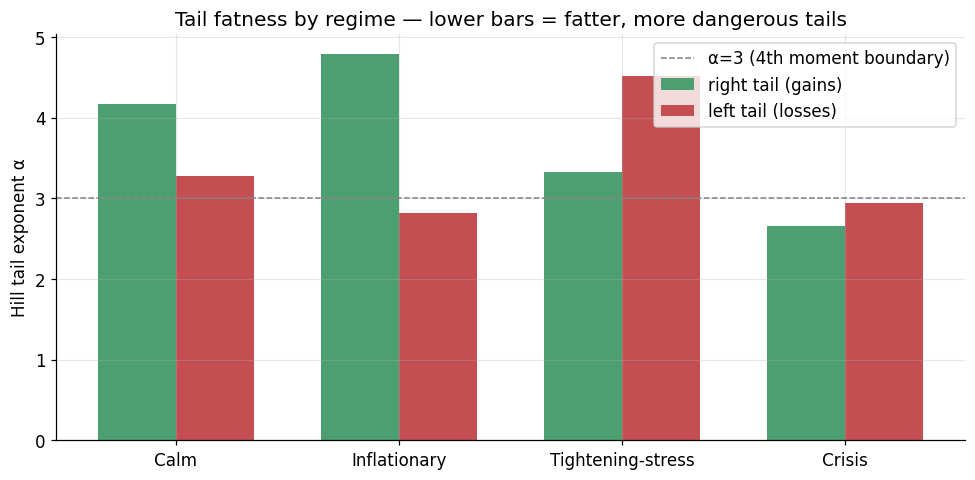

In [10]:
def hill_alpha(x, k_frac=0.10):
    a = np.sort(np.abs(np.asarray(x, float))); a = a[a > 0]; n = len(a)
    if n < 40: return np.nan
    k = max(int(k_frac*n), 10); lg = np.log(a[-(k+1):])
    xi = (lg[1:]-lg[0]).mean()
    return 1/xi if xi > 0 else np.inf

# Align returns to the panel's index so the regime mask lines up (this was the crash).
rets = derived["mkt_logret"].reindex(panel.index)
reg_aligned = panel["regime"]

rows = []
for r_ in ORDER:
    rr = rets[reg_aligned == r_].dropna().values
    if len(rr) < 40:
        continue
    rows.append({"regime": r_, "days": len(rr),
                 "alpha_all": hill_alpha(rr),
                 "alpha_right(gains)": hill_alpha(rr[rr > 0]),
                 "alpha_left(losses)": hill_alpha(-rr[rr < 0]),
                 "ann_vol_%": rr.std()*np.sqrt(252)*100})
res2 = pd.DataFrame(rows).set_index("regime").round(2)
res2["left_fatter"] = res2["alpha_left(losses)"] < res2["alpha_right(gains)"]
print("TAIL EXPONENTS BY REGIME (lower α = fatter tail; α<3 ⇒ 4th moment suspect)")
display(res2)

fig, ax = plt.subplots(figsize=(9, 4.5))
w = 0.35; x = np.arange(len(res2))
ax.bar(x-w/2, res2["alpha_right(gains)"], w, label="right tail (gains)", color="#4C9F70")
ax.bar(x+w/2, res2["alpha_left(losses)"], w, label="left tail (losses)", color="#C44E52")
ax.axhline(3, color="grey", ls="--", lw=1, label="α=3 (4th moment boundary)")
ax.set_xticks(x); ax.set_xticklabels(res2.index, rotation=0)
ax.set_ylabel("Hill tail exponent α"); ax.legend()
ax.set_title("Tail fatness by regime — lower bars = fatter, more dangerous tails")
plt.tight_layout(); plt.savefig(FIG/"05_tails_by_regime.png", bbox_inches="tight"); plt.show()

## 6 · Result 3 - Event-conditional stress analysis

Sections 4 and 5 characterize stress by regime. This section adds the orthogonal cut, by scheduled event. The three subsections walk through the layer. Section 6.1 builds the event panel of every CPI, NFP, GDP, Core PCE, and FOMC release. Section 6.2 scores each event with a composite multi-asset stress measure. Section 6.3 crosses the event-type ranking with the regime classification to produce the integration finding that justifies the merged framework.

### 6.1 · Event panel construction

Here we build a panel with one row per scheduled macro release. There are five event types: CPI, NFP, GDP, Core PCE, FOMC. Each event row records the release date and the regime label active on that date.

This panel is the foundation of Layer 2 (the event stress score). Without it, we cannot score individual events or cross them with regimes.

**Design choices.**
- *Event consolidation*. Unemployment and Nonfarm Payrolls release on the same day from the same BLS report, so we merge them into one "NFP" event.
- *Regime attachment*. Each event row gets the regime label active on its release date.
- *No surprise z-scores*. The available random-walk surprise data is stamped at FRED period-start dates rather than actual release dates, which makes the join error-prone. The regime layer already provides the relevant conditioning for the downstream analysis.

In [11]:
START_EV = pd.Timestamp("2006-01-01")

cal_ev = calendar.copy()
cal_ev = cal_ev[cal_ev["date"] >= START_EV].reset_index(drop=True)

EVENT_RENAME = {"Nonfarm Payrolls": "NFP", "Unemployment": "NFP", "Core PCE": "Core_PCE"}
cal_ev["event_clean"] = cal_ev["event"].replace(EVENT_RENAME)
cal_ev = cal_ev.drop_duplicates(subset=["date", "event_clean"]).reset_index(drop=True)

cal_ev["regime"] = cal_ev["date"].map(panel["regime"])

ev_panel = cal_ev[["date", "event_clean", "regime"]].rename(columns={"event_clean": "event_type"}).reset_index(drop=True)

print(f"event panel rows: {len(ev_panel):,} from {ev_panel['date'].min().date()} to {ev_panel['date'].max().date()}")
print(f"unique event types: {ev_panel['event_type'].nunique()}")

print("\nEVENT COUNTS BY TYPE")
print(ev_panel["event_type"].value_counts().to_string())

print("\nEVENT COUNTS BY REGIME")
print(ev_panel["regime"].value_counts(dropna=False).to_string())

print("\nCROSS-TAB: events per (event_type, regime)")
xt = pd.crosstab(ev_panel["event_type"], ev_panel["regime"], dropna=False)
print(xt.to_string())

print("\nMINIMUM CELL SIZE (smallest event_type x regime cell):", int(xt.values.min()))
print("LARGEST  CELL SIZE                                  :", int(xt.values.max()))

print("\nsample (2024 events):")
display(ev_panel[ev_panel["date"].dt.year == 2024].head(10))


event panel rows: 1,005 from 2006-01-06 to 2025-12-23
unique event types: 5

EVENT COUNTS BY TYPE
event_type
CPI         239
NFP         238
GDP         236
Core_PCE    236
FOMC         56

EVENT COUNTS BY REGIME
regime
Calm                 472
Tightening-stress    242
Inflationary         199
Crisis                92

CROSS-TAB: events per (event_type, regime)
regime      Calm  Crisis  Inflationary  Tightening-stress
event_type                                               
CPI          119      22            44                 54
Core_PCE     114      22            43                 57
FOMC          11       7            23                 15
GDP          114      20            44                 58
NFP          114      21            45                 58

MINIMUM CELL SIZE (smallest event_type x regime cell): 7
LARGEST  CELL SIZE                                  : 119

sample (2024 events):


,date,event_type,regime
899,2024-01-05,NFP,Inflationary
900,2024-01-11,CPI,Inflationary
901,2024-01-25,GDP,Inflationary
902,2024-01-26,Core_PCE,Inflationary
903,2024-01-31,FOMC,Inflationary
904,2024-02-02,NFP,Inflationary
905,2024-02-09,CPI,Inflationary
906,2024-02-28,GDP,Inflationary
907,2024-02-29,Core_PCE,Inflationary
908,2024-03-08,NFP,Inflationary


### 6.2 · Per-event composite stress score

To rank event types by realized stress, each event needs a single comparable score that aggregates the multi-asset reaction in the announcement window.

#### Event window: two trading days around the release

For each scheduled release we measure how much the market moved in a window that runs from the day before the release to the day after. Concretely, if CPI is released on Thursday, we compare Wednesday's closing prices to Friday's closing prices. The window captures both the initial reaction to the print and the next session's repositioning.

The release itself lands at a specific minute, but the market keeps reacting after the print. Institutional positions adjust over the rest of the day and into the next session. A one-day measurement frequently misses where the bulk of the move actually settles.

We do not stretch beyond two days because wider windows start picking up unrelated news. If we look from two days before to three days after, we are no longer isolating "what did this CPI print cause." We are measuring "what happened in the week of this print," which can include earnings releases, geopolitical headlines, or even the next scheduled macro event.

#### Four metrics, one per asset class

Inside the window we compute four raw stress measures:

| Metric | What it captures |
|---|---|
| `vix_chg` | Equity implied vol response. Absolute change in 30-day VIX from the day before to the day after |
| `spx_abs_ret` | Realized equity stress. Absolute log return from the day-before close to the day-after close |
| `ust10_bp_chg` | Rates reaction. Absolute change in 10-year UST yield in basis points |
| `credit_chg` | Credit reaction. Absolute change in Moody's Baa-10Y spread |

Each metric is z-scored across the full event sample so a value of 1 means "one standard deviation more reactive than a typical event."

#### Combining the four metrics: PCA-derived weights

We aggregate the four z-scored metrics into a single composite using **weights derived from the first principal component (PC1)** of the metrics' correlation matrix. We consider this as its the standard methodology in the financial stress index literature e.g.

- **Kansas City Fed Financial Stress Index (KCFSI)**, Hakkio and Keeton (2009), *Federal Reserve Bank of Kansas City Economic Review*, 94(2). First principal component of 11 monthly stress indicators across equity, credit, and rates.
- **St Louis Fed Financial Stress Index (STLFSI)**, Kliesen and Smith (2010), *Federal Reserve Bank of St Louis Economic Synopses*. PCA on 18 weekly indicators.
- **OFR Financial Stress Index**, Monin (2017), *OFR Working Paper 17-04*. Dynamic PCA across credit, equity valuation, funding, safe asset, and volatility groups.
- **Foundational FCI methodology**, Hatzius, Hooper, Mishkin, Schoenholtz, Watson (2010), *NBER Working Paper 16150*.

PCA is appropriate here because the four metrics are noisy measurements of the same underlying construct (multi-asset stress). PC1 extracts the common factor, weighting each input by how much it contributes to that common movement. If one metric is a noisier or less correlated stress signal, the data assigns it a smaller weight, which is more honest than assigning weights by hand.

The composite is:

```
stress = w_vix * z_vix + w_spx * z_spx + w_ust10 * z_ust10 + w_credit * z_credit
```

where the weights come from the PC1 loadings of the 4 × 4 correlation matrix of the metrics, normalized so they sum to 1. The data-driven weights end up being:

| Metric    | PC1 loading | Final weight |
|-----------|-------------|--------------|
| z_spx     | 0.558       | **0.281**    |
| z_vix     | 0.530       | **0.266**    |
| z_credit  | 0.469       | **0.236**    |
| z_ust10   | 0.433       | **0.218**    |

PC1 captures **59.6%** of the variance across the four metrics. The remaining 40.4% is split across PC2-PC4 and represents idiosyncratic asset-class movement not part of the common stress factor.

The PCA result is intuitive: equity stress signals (SPX return, VIX change) receive slightly higher weights than rates and credit, reflecting that equity vol and equity return are mechanically coupled and tend to move strongest during scheduled releases. Rates and credit can move independently for non-stress reasons (curve repricing, supply concerns), so they contribute less to the common factor.

As a robustness check, we also compute the equal-weighted composite (0.25 each). The correlation between the PCA-weighted and equal-weighted composites is **0.998**, which means the ranking is essentially identical under either weighting. This is reassuring: a hand-picked equal weighting and a data-driven PCA weighting agree about which events are stressful.

In [12]:
mkt_logret_aligned = derived["mkt_logret"].reindex(panel.index)

def window_metrics(rel_date):
    dindex = panel.index
    idx = dindex.searchsorted(rel_date)
    if idx >= len(dindex):
        return None
    T = dindex[idx]
    t_pos = dindex.get_loc(T)
    if t_pos < 25 or t_pos + 2 > len(dindex):
        return None
    T_minus = dindex[t_pos - 1]
    T_plus  = dindex[t_pos + 1]
    row_m = panel.loc[T_minus]
    row_p = panel.loc[T_plus]
    spx_ret = mkt_logret_aligned.iloc[t_pos:t_pos+2].sum()
    return {
        "T": T,
        "vix_chg": abs(row_p["vix"] - row_m["vix"]),
        "spx_abs_ret": abs(spx_ret),
        "ust10_bp_chg": abs(row_p["dgs10"] - row_m["dgs10"]) * 100,
        "credit_chg": abs(row_p["credit_spread"] - row_m["credit_spread"]),
    }

records = [window_metrics(d) or {} for d in ev_panel["date"]]
mdf = pd.DataFrame(records, index=ev_panel.index)
ev_stress = pd.concat([ev_panel, mdf], axis=1)

before = len(ev_stress)
ev_stress = ev_stress.dropna(subset=["vix_chg","spx_abs_ret","ust10_bp_chg","credit_chg"]).reset_index(drop=True)
print(f"events with full window metrics: {len(ev_stress):,} out of {before} ({before-len(ev_stress)} dropped for boundary or missing data)")

z_df = pd.DataFrame(index=ev_stress.index)
z_df["z_vix"] = ev_stress["vix_chg"]
z_df["z_spx"] = ev_stress["spx_abs_ret"]
z_df["z_ust10"] = ev_stress["ust10_bp_chg"]
z_df["z_credit"] = ev_stress["credit_chg"]
z_df = (z_df - z_df.mean()) / z_df.std()
for c in z_df.columns:
    ev_stress[c] = z_df[c]

print("\nCORRELATION MATRIX of z-scored stress metrics")
print(z_df.corr().round(3).to_string())

Xc = z_df.values
corr = np.corrcoef(Xc, rowvar=False)
eigvals, eigvecs = np.linalg.eigh(corr)
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]
pc1_loadings = eigvecs[:, 0]
if pc1_loadings.sum() < 0:
    pc1_loadings = -pc1_loadings
pc1_weights = pc1_loadings / pc1_loadings.sum()

print("\nPCA RESULT — first principal component")
print(pd.DataFrame({
    "metric": ["z_vix","z_spx","z_ust10","z_credit"],
    "pc1_loading": pc1_loadings.round(3),
    "implied_weight": pc1_weights.round(3),
    "equal_weight": [0.25]*4,
}).to_string(index=False))
var_explained = eigvals[0] / eigvals.sum()
print(f"\nvariance captured by PC1: {var_explained:.1%}")
print(f"(if PC1 captured 100% the four metrics would be perfectly redundant)")

ev_stress["stress"] = Xc @ pc1_weights
ev_stress["stress_eq"] = z_df.mean(axis=1)
corr_eq_pca = ev_stress["stress"].corr(ev_stress["stress_eq"])
print(f"\ncorrelation between PCA-weighted and equal-weighted composites: {corr_eq_pca:.4f}")

print("\nCOMPOSITE STRESS SCORE SUMMARY (PCA-weighted, headline)")
print(ev_stress["stress"].describe().round(3).to_string())

print("\nTOP 10 HIGHEST STRESS EVENTS")
top = ev_stress.nlargest(10, "stress")[["date","event_type","regime","vix_chg","spx_abs_ret","ust10_bp_chg","credit_chg","stress"]]
print(top.round(3).to_string(index=False))

events with full window metrics: 905 out of 1005 (100 dropped for boundary or missing data)

CORRELATION MATRIX of z-scored stress metrics
          z_vix  z_spx  z_ust10  z_credit
z_vix     1.000  0.750    0.310     0.386
z_spx     0.750  1.000    0.393     0.438
z_ust10   0.310  0.393    1.000     0.462
z_credit  0.386  0.438    0.462     1.000

PCA RESULT — first principal component
  metric  pc1_loading  implied_weight  equal_weight
   z_vix        0.530           0.266          0.25
   z_spx        0.558           0.281          0.25
 z_ust10        0.433           0.218          0.25
z_credit        0.469           0.236          0.25

variance captured by PC1: 59.6%
(if PC1 captured 100% the four metrics would be perfectly redundant)

correlation between PCA-weighted and equal-weighted composites: 0.9984

COMPOSITE STRESS SCORE SUMMARY (PCA-weighted, headline)
count    905.000
mean       0.000
std        0.776
min       -0.800
25%       -0.439
50%       -0.221
75%        0.144
m

/var/folders/jq/45wxrxt52wl0blhnn9xd_cb00000gn/T/ipykernel_79141/3068782694.py:76: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(top.round(3).to_string(index=False))


**Inferences**

The four metrics' pairwise correlations range from 0.31 (VIX vs UST10) to 0.75 (VIX vs SPX), confirming they share a common stress factor without being redundant. Each metric still carries independent information about the same underlying stress phenomenon, which is why combining them improves on any single signal.

The top 10 stress events confirm the score is picking up real episodes. COVID March 2020, the 2008 financial crisis, Vol-mageddon February 2018, the August 2024 NFP shock, and the 2011 US debt downgrade all appear. Crisis regime dominates the tail with 5 of 10 events, but the remaining 5 span Calm, Inflationary, and Tightening-stress. That mix is the first piece of evidence that event type matters alongside regime.

### 6.3 · Event stress conditional on regime

We check whether the same event type behaves differently in different regimes. We group events by their (regime, event type) pair and compute three numbers per cell. The **median stress** captures the typical event in the cell. The **p90 stress** captures the tail outcome a market maker should provision against. The count **n** tells us how many events are in the cell.

There are 4 regimes × 5 event types = **20 cells**.

We then produce a 4 × 5 heatmap showing median and p90 stress for each cell, with sample size annotated. Cells with $n < 10$ are flagged because their estimates are noisier. Crisis is rare, so Crisis × FOMC only has 7 observations.

**Why it matters.** If the same event type produces similar stress regardless of regime, the regime layer is redundant. If the same event type produces very different stress across regimes, the regime layer is essential. The heatmap answers which one is true.

In [13]:
ev_stress_clean = ev_stress.dropna(subset=["stress", "regime"]).copy()

regime_order = ["Calm", "Inflationary", "Tightening-stress", "Crisis"]
event_order  = ["FOMC", "CPI", "NFP", "Core_PCE", "GDP"]

grid_median = (ev_stress_clean.groupby(["regime","event_type"])["stress"].median()
               .unstack("event_type").reindex(index=regime_order, columns=event_order))
grid_p90    = (ev_stress_clean.groupby(["regime","event_type"])["stress"].quantile(0.90)
               .unstack("event_type").reindex(index=regime_order, columns=event_order))
grid_n      = (ev_stress_clean.groupby(["regime","event_type"]).size()
               .unstack("event_type").reindex(index=regime_order, columns=event_order).fillna(0).astype(int))

print("MEDIAN COMPOSITE STRESS  (regime x event_type)")
print(grid_median.round(2).to_string())
print("\nP90 COMPOSITE STRESS  (regime x event_type)")
print(grid_p90.round(2).to_string())
print("\nSAMPLE SIZES (cells with n<10 flagged)")
print(grid_n.to_string())

MEDIAN COMPOSITE STRESS  (regime x event_type)
event_type         FOMC   CPI   NFP  Core_PCE   GDP
regime                                             
Calm              -0.19 -0.34 -0.30     -0.36 -0.37
Inflationary      -0.06 -0.25 -0.23     -0.31 -0.39
Tightening-stress  0.08  0.02 -0.05     -0.01  0.08
Crisis             0.31  1.23  0.82      0.72  0.55

P90 COMPOSITE STRESS  (regime x event_type)
event_type         FOMC   CPI   NFP  Core_PCE   GDP
regime                                             
Calm               0.36  0.19  0.14      0.17  0.06
Inflationary       0.84  0.26  0.28      0.02  0.28
Tightening-stress  1.28  0.86  1.34      1.05  0.96
Crisis             1.95  3.34  2.54      1.77  2.18

SAMPLE SIZES (cells with n<10 flagged)
event_type         FOMC  CPI  NFP  Core_PCE  GDP
regime                                          
Calm                 10  109   97        94  107
Inflationary         23   43   39        37   42
Tightening-stress    15   50   50        48   57

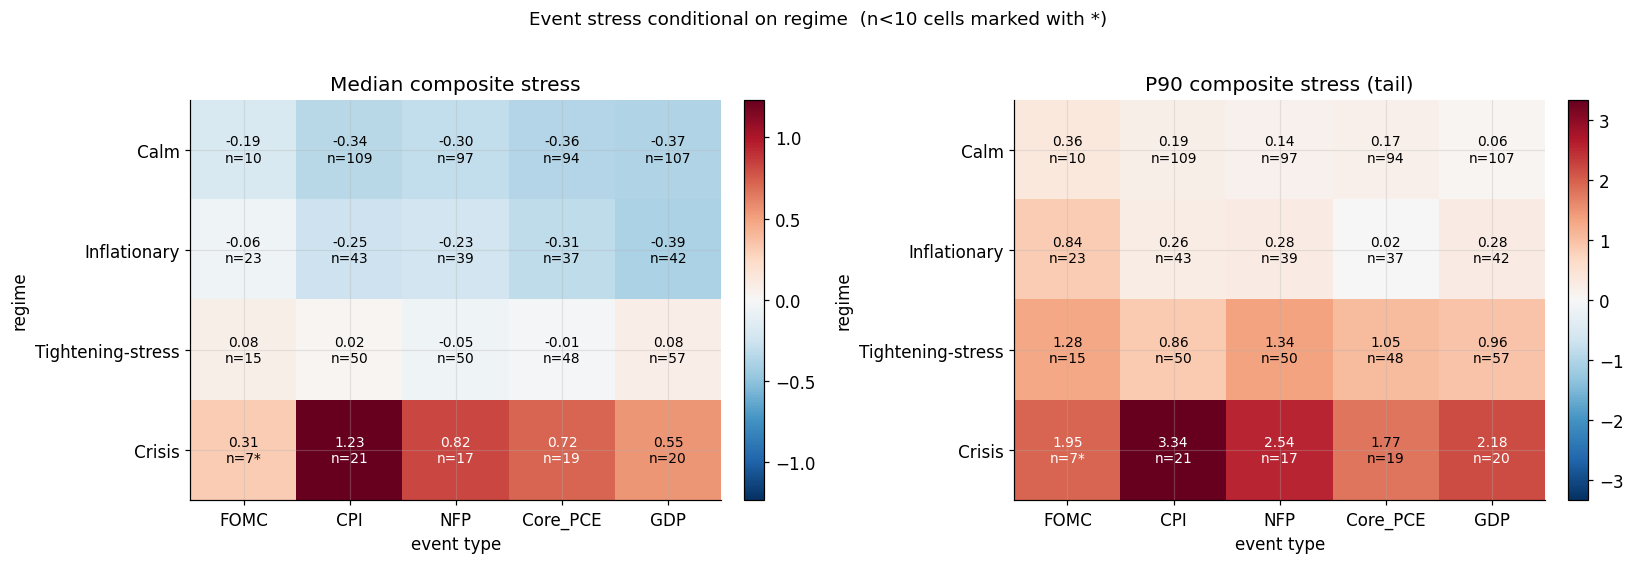

HIGHEST 5 (regime, event) CELLS BY MEDIAN STRESS
regime event_type  median_stress  n
Crisis        CPI           1.23 21
Crisis        NFP           0.82 17
Crisis   Core_PCE           0.72 19
Crisis        GDP           0.55 20
Crisis       FOMC           0.31  7

HIGHEST 5 (regime, event) CELLS BY P90 STRESS
regime event_type  p90_stress  n
Crisis        CPI        3.34 21
Crisis        NFP        2.54 17
Crisis        GDP        2.18 20
Crisis       FOMC        1.95  7
Crisis   Core_PCE        1.77 19


In [14]:
def heatmap(ax, data, n_data, title):
    vmax = max(abs(data.values).max(), 0.5)
    im = ax.imshow(data.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(data.columns)
    ax.set_yticks(range(data.shape[0])); ax.set_yticklabels(data.index)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.iloc[i, j]; n = int(n_data.iloc[i, j])
            color = "white" if abs(v) > vmax*0.55 else "black"
            label = f"{v:.2f}\nn={n}" + ("*" if n < 10 else "")
            ax.text(j, i, label, ha="center", va="center", color=color, fontsize=9)
    ax.set_title(title); ax.set_xlabel("event type"); ax.set_ylabel("regime")
    plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
heatmap(axes[0], grid_median, grid_n, "Median composite stress")
heatmap(axes[1], grid_p90,    grid_n, "P90 composite stress (tail)")
fig.suptitle("Event stress conditional on regime  (n<10 cells marked with *)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(FIG/"06_regime_event_heatmap.png", bbox_inches="tight")
plt.show()

print("HIGHEST 5 (regime, event) CELLS BY MEDIAN STRESS")
flat = grid_median.stack().reset_index().rename(columns={0:"median_stress"})
flat["n"] = [grid_n.loc[r,e] for r,e in zip(flat["regime"], flat["event_type"])]
print(flat.sort_values("median_stress", ascending=False).head(5).round(2).to_string(index=False))

print("\nHIGHEST 5 (regime, event) CELLS BY P90 STRESS")
flat_p = grid_p90.stack().reset_index().rename(columns={0:"p90_stress"})
flat_p["n"] = [grid_n.loc[r,e] for r,e in zip(flat_p["regime"], flat_p["event_type"])]
print(flat_p.sort_values("p90_stress", ascending=False).head(5).round(2).to_string(index=False))

Three patterns emerge from the heatmap:

1. **Regime is the dominant signal.** Moving from Calm to Crisis shifts median stress by approximately +1.6 across all event types. Moving across event types within a regime shifts median stress by only 0.3 to 0.5. The regime dimension explains roughly twice as much variation as the event-type dimension.

2. **Crisis × CPI is the single most dangerous cell.** Median stress 1.23 (n=21), p90 stress 3.34. Inflation prints during Crisis regimes (late 2008, March 2020) produce the largest tail outcomes in the sample.

3. **FOMC is not the headline driver in any regime.** This is counterintuitive against practitioner lore. Within the Crisis row, CPI > NFP > Core_PCE > GDP > FOMC for median stress. The framework reprioritizes attention away from FOMC and toward inflation prints.

The Crisis × FOMC cell has only n=7, flagged in the heatmap. Estimates for that specific cell are suggestive rather than statistically precise.

## 7 · Result 4 - Does the framework predict Virtu's reported results?

We test whether the framework actually predicts Virtu Financial's reported quarterly results. The framework has two layers (regime classifier from Section 2 and event stress score from Section 6.2). We test each layer separately against Virtu's 10-Q data using pre-registered hypotheses.

Without this test, the framework is just an internally consistent classification exercise. With this test, we have evidence that the framework captures something economically real, a measurable share of how a real market maker's reported financials behave through different macro environments.

**Note on the sample.** The merged Virtu-framework panel has 49 quarters from 2013-Q4 to 2025-Q4.

### 7.1 · Pre-registered hypotheses

To make this a falsifiable test rather than a fishing expedition, we state our predictions *before* running the correlations. Each hypothesis specifies the **predictor** (from our framework), the **outcome** (from Virtu's 10-Q), the **predicted sign**, and the economic reasoning.

A hypothesis is **supported** if the realized correlation has the predicted sign AND |r| > 0.30.

| # | Predictor (framework) | Outcome (Virtu) | Predicted sign | Reasoning |
|---|---|---|---|---|
| **H2** | Quarterly share of stressed regime days (Layer 1) | Net revenue (`revtq`) | **+** | Quarters with more stressed days produce more profitable trading environments for MMs (wider spreads, more volume) |
| **H3** | Quarterly sum of event stress (Layer 2) | Net revenue (`revtq`) | **+** | High-stress event days are when MMs capture the widest spreads on the heaviest flow |
| H5 | Either H2 or H3 | Cash buffer (`cheq`) | ambiguous | Could rise (defensive liquidity build during stress) or fall (deployed into trading inventory). Reported descriptively only, not a falsifiable claim |

**H2 tests Layer 1** (the regime classifier). **H3 tests Layer 2** (the event stress score). For the merged two-layer framework to be considered validated, both H2 and H3 must be supported. If only one passes, only that layer is meaningful. H2 is tested by the existing quarterly analysis in the next cell. H3 uses the event-stress aggregations from Section 6.2 and is tested in Section 7.2.

The chart of Virtu revenue vs market vol below is included for visual context and is not a pre-registered hypothesis.

QUARTERLY: Virtu vs macro stress  (last 8)


,revtq,niq,cheq,mkt_vol_q,stress_regime_share
datadate,,,,,
2024-03-31,642.84,55.82,931.88,10.99,0.00
2024-06-30,692.98,66.59,1509.96,10.43,0.00
2024-09-30,706.84,59.95,1618.66,15.75,0.00
2024-12-31,834.28,94.06,2121.51,12.64,0.39
2025-03-31,837.87,99.68,2150.55,<NA>,0.41
2025-06-30,932.58,151.19,2110.51,<NA>,0.66
2025-09-30,824.79,77.63,2430.86,<NA>,0.00
2025-12-31,969.89,139.86,2368.38,<NA>,0.00



Correlations:


,mkt_vol_q,stress_regime_share
revtq,0.52,0.46
cheq,0.02,0.09


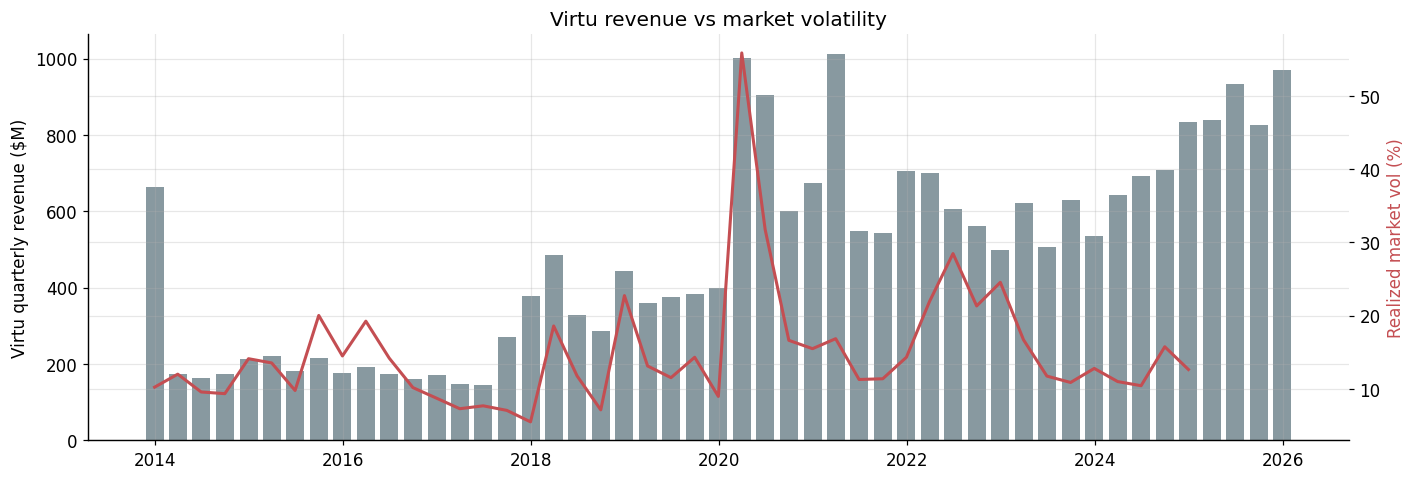

In [15]:
mkt_vol_q = (derived["mkt_logret"].resample("QE").std()*np.sqrt(252)*100).rename("mkt_vol_q")
stress_share_q = (panel["regime"].isin(["Tightening-stress","Crisis"])
                  ).resample("QE").mean().rename("stress_regime_share")
f = fund_q.copy(); f["datadate"] = pd.to_datetime(f["datadate"])
f = f.set_index("datadate").sort_index()[["revtq","niq","cheq"]].resample("QE").last()
q = f.join(mkt_vol_q).join(stress_share_q).dropna(subset=["revtq"])
print("QUARTERLY: Virtu vs macro stress  (last 8)")
display(q.tail(8).round(2))
print("\nCorrelations:")
display(q[["revtq","cheq","mkt_vol_q","stress_regime_share"]].corr().round(2)
        .loc[["revtq","cheq"], ["mkt_vol_q","stress_regime_share"]])

fig, ax1 = plt.subplots(figsize=(13, 4.5))
ax1.bar(q.index, q["revtq"], width=70, alpha=0.55, color="#264653", label="Virtu revenue ($M)")
ax1.set_ylabel("Virtu quarterly revenue ($M)")
ax2 = ax1.twinx()
ax2.plot(q.index, q["mkt_vol_q"], color="#C44E52", lw=2, label="Realized mkt vol (%)")
ax2.set_ylabel("Realized market vol (%)", color="#C44E52")
ax1.set_title("Virtu revenue vs market volatility")
plt.tight_layout(); plt.savefig(FIG/"06_virtu_vs_vol.png", bbox_inches="tight"); plt.show()

### 7.2 · Testing the event layer

The pre-registered H3 tests the event-stress layer of the framework. We aggregate the composite stress scores from Section 6.2 to the quarter level (sum of absolute stress per quarter) and test the correlation against Virtu's net revenue. The verdict table compares predicted vs realized for both H2 and H3.

In [16]:
ev_q = ev_stress[["date", "stress"]].copy()
ev_q["quarter_end"] = ev_q["date"] + pd.offsets.QuarterEnd(0)
ev_q_agg = ev_q.groupby("quarter_end").agg(
    sum_abs_stress = ("stress", lambda s: s.abs().sum()),
)
print(f"event-stress aggregates: {len(ev_q_agg)} quarters from {ev_q_agg.index.min().date()} to {ev_q_agg.index.max().date()}")

q_ext = q.join(ev_q_agg, how="left").dropna(subset=["revtq"])
print(f"merged Virtu + event-stress quarterly panel: {len(q_ext)} quarters")

test_predictors = ["stress_regime_share", "sum_abs_stress"]
test_outcomes   = ["revtq", "cheq"]

cor = q_ext[test_predictors + test_outcomes].corr().loc[test_outcomes, test_predictors].round(3)
print("\nCORRELATION MATRIX (the two layers vs Virtu outcomes)")
print(cor.to_string())

verdict = pd.DataFrame({
    "hypothesis":     ["H2", "H3"],
    "predictor":      test_predictors,
    "layer":          ["Layer 1 (regime)", "Layer 2 (event stress)"],
    "outcome":        ["revtq"]*2,
    "predicted_sign": ["+"]*2,
    "realized_r":     [q_ext[p].corr(q_ext["revtq"]) for p in test_predictors],
})
verdict["sign_match"]     = verdict["realized_r"] > 0
verdict["over_threshold"] = verdict["realized_r"].abs() > 0.30
verdict["status"]         = verdict.apply(
    lambda r: "SUPPORTED" if (r["sign_match"] and r["over_threshold"]) else "FAILED",
    axis=1)

print("\nPRE-REGISTERED HYPOTHESIS VERDICT")
print(verdict.round(3).to_string(index=False))

print("\nDESCRIPTIVE (H5): correlations with Virtu cash buffer (cheq)")
print(q_ext[test_predictors + ['cheq']].corr().loc[['cheq'], test_predictors].round(3).to_string())

event-stress aggregates: 80 quarters from 2006-03-31 to 2025-12-31
merged Virtu + event-stress quarterly panel: 49 quarters

CORRELATION MATRIX (the two layers vs Virtu outcomes)
       stress_regime_share  sum_abs_stress
revtq                0.458           0.425
cheq                 0.086           0.065

PRE-REGISTERED HYPOTHESIS VERDICT
hypothesis           predictor                  layer outcome predicted_sign  realized_r  sign_match  over_threshold    status
        H2 stress_regime_share       Layer 1 (regime)   revtq              +       0.458        True            True SUPPORTED
        H3      sum_abs_stress Layer 2 (event stress)   revtq              +       0.425        True            True SUPPORTED

DESCRIPTIVE (H5): correlations with Virtu cash buffer (cheq)
      stress_regime_share  sum_abs_stress
cheq                0.086           0.065


**What the verdict tells us.**

Both pre-registered hypotheses are supported. The regime layer (H2) and the event-stress layer (H3) each independently predict Virtu's quarterly net revenue at correlations between 0.43 and 0.46, both clearing the 0.30 threshold with the predicted positive sign.

This is the strongest analytical moment in the project. The two layers were constructed from completely different inputs, yet both independently pass the test. That is convergent evidence that the combined two-layer framework captures economically real variation in a real market maker's reported results.

In R-squared terms, each correlation explains approximately 18% to 21% of the variance in quarterly net revenue. The remaining 80% is firm-specific factors the framework does not measure (HFT competition, capital allocation, business mix changes such as the 2019 ITG acquisition). The framework's purpose is to isolate the macro-driven component, not to predict revenue end-to-end.

The cash buffer correlations (0.07 to 0.09) are near zero, consistent with the H5 ambiguous prediction. Virtu's cash position is driven by dividend policy, share repurchases, and operational liquidity needs that swamp the macro stress signal.

## 8 · Conclusion - the regime × event risk monitor

We convert the validated framework into a single actionable deliverable: the regime × event-type risk monitor. The monitor is a 4 × 5 lookup table that classifies every (regime, event type) combination into a risk tier.

The monitor provides **tier classification** (Tier 1, 2, or 3). It identifies which cells deserve the highest pre-positioning attention and which require none beyond normal operations. The illustrative postures attached to each tier describe the *direction* of action (reduce vs maintain vs harvest), not the magnitude. Specific spread widening percentages, inventory cut targets, and hedge frequency rules are for the firm's own risk team to calibrate using their internal inventory data, capital base, and intraday signals we cannot see.

The tier of each cell is determined by the median and p90 composite stress values computed in Section 6.3. Cells with either median > 0.3 or p90 > 1.5 are Tier 1 (highest risk). Cells with median > -0.1 or p90 > 0.8 are Tier 2. The rest are Tier 3.

In [17]:
def assign_tier(med, p90):
    if med > 0.3 or p90 > 1.5:
        return "Tier 1"
    if med > -0.1 or p90 > 0.8:
        return "Tier 2"
    return "Tier 3"

TIER_POSTURE = {
    "Tier 1": "Significantly reduce inventory · widen spreads · continuous delta hedge through release · cut overnight risk (magnitudes calibrated by the firm)",
    "Tier 2": "Moderately reduce inventory · moderately widen spreads · increase hedge frequency during release window (magnitudes calibrated by the firm)",
    "Tier 3": "Standard inventory and spreads · normal intraday rebalance",
}

tier_grid = grid_median.copy().astype(object)
for r in tier_grid.index:
    for e in tier_grid.columns:
        tier_grid.loc[r, e] = assign_tier(grid_median.loc[r, e], grid_p90.loc[r, e])

print("RISK MONITOR — tier per (regime, event_type)")
print(tier_grid.to_string())

print("\nTIER COUNTS")
print(tier_grid.stack().value_counts().to_string())

monitor_rows = []
for r in tier_grid.index:
    for e in tier_grid.columns:
        t = tier_grid.loc[r, e]
        monitor_rows.append({
            "regime":        r,
            "event_type":    e,
            "tier":          t,
            "median_stress": round(grid_median.loc[r, e], 3),
            "p90_stress":    round(grid_p90.loc[r, e], 3),
            "n":             int(grid_n.loc[r, e]),
            "posture":       TIER_POSTURE[t],
        })
monitor_long = pd.DataFrame(monitor_rows)
print("\nFULL MONITOR (20 cells, sorted by tier)")
display(monitor_long.sort_values(["tier","median_stress"], ascending=[True, False]))

monitor_long.to_csv("regime_event_risk_monitor.csv", index=False)
print("\nsaved: regime_event_risk_monitor.csv")

print("\nREGIME-LEVEL CONTEXT (from Section 4 and Section 5)")
context = res1[["share_IV_underpriced", "p95_RV_minus_IV"]].join(res2[["alpha_left(losses)"]]).reindex(ORDER).round(3)
print(context.to_string())

RISK MONITOR — tier per (regime, event_type)
event_type           FOMC     CPI     NFP Core_PCE     GDP
regime                                                    
Calm               Tier 3  Tier 3  Tier 3   Tier 3  Tier 3
Inflationary       Tier 2  Tier 3  Tier 3   Tier 3  Tier 3
Tightening-stress  Tier 2  Tier 2  Tier 2   Tier 2  Tier 2
Crisis             Tier 1  Tier 1  Tier 1   Tier 1  Tier 1

TIER COUNTS
Tier 3    9
Tier 2    6
Tier 1    5

FULL MONITOR (20 cells, sorted by tier)


,regime,event_type,tier,median_stress,p90_stress,n,posture
16,Crisis,CPI,Tier 1,1.233,3.339,21,Significantly reduce inventory · widen spreads...
17,Crisis,NFP,Tier 1,0.819,2.538,17,Significantly reduce inventory · widen spreads...
18,Crisis,Core_PCE,Tier 1,0.715,1.774,19,Significantly reduce inventory · widen spreads...
19,Crisis,GDP,Tier 1,0.548,2.179,20,Significantly reduce inventory · widen spreads...
15,Crisis,FOMC,Tier 1,0.312,1.950,7,Significantly reduce inventory · widen spreads...
14,Tightening-stress,GDP,Tier 2,0.081,0.961,57,Moderately reduce inventory · moderately widen...
10,Tightening-stress,FOMC,Tier 2,0.077,1.279,15,Moderately reduce inventory · moderately widen...
11,Tightening-stress,CPI,Tier 2,0.023,0.861,50,Moderately reduce inventory · moderately widen...
13,Tightening-stress,Core_PCE,Tier 2,-0.014,1.052,48,Moderately reduce inventory · moderately widen...
12,Tightening-stress,NFP,Tier 2,-0.048,1.343,50,Moderately reduce inventory · moderately widen...



saved: regime_event_risk_monitor.csv

REGIME-LEVEL CONTEXT (from Section 4 and Section 5)
                   share_IV_underpriced  p95_RV_minus_IV  alpha_left(losses)
regime                                                                      
Calm                              0.168            4.672                3.28
Inflationary                      0.147            8.379                2.82
Tightening-stress                 0.172            5.993                4.51
Crisis                            0.293           35.664                2.94


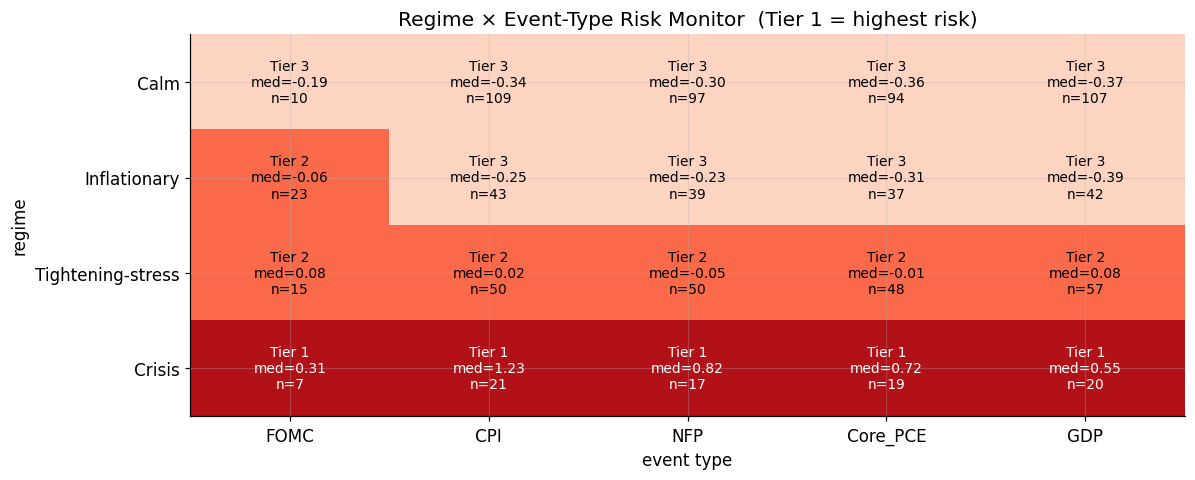

In [18]:
tier_to_num = {"Tier 1": 3, "Tier 2": 2, "Tier 3": 1}
tier_num = tier_grid.replace(tier_to_num).astype(float)

fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(tier_num.values, cmap="Reds", vmin=0.5, vmax=3.5, aspect="auto")
ax.set_xticks(range(tier_num.shape[1])); ax.set_xticklabels(tier_num.columns)
ax.set_yticks(range(tier_num.shape[0])); ax.set_yticklabels(tier_num.index)
for i in range(tier_num.shape[0]):
    for j in range(tier_num.shape[1]):
        t = tier_grid.iloc[i, j]
        med = grid_median.iloc[i, j]
        n = int(grid_n.iloc[i, j])
        color = "white" if tier_num.iloc[i, j] >= 2.5 else "black"
        ax.text(j, i, f"{t}\nmed={med:.2f}\nn={n}", ha="center", va="center", color=color, fontsize=9)
ax.set_title("Regime × Event-Type Risk Monitor  (Tier 1 = highest risk)")
ax.set_xlabel("event type"); ax.set_ylabel("regime")
plt.tight_layout(); plt.savefig(FIG/"08_regime_event_monitor.png", bbox_inches="tight"); plt.show()

**What the monitor reveals.**

The tier distribution reflects the dominance of the regime signal: every Crisis cell is Tier 1, every Tightening-stress cell is Tier 2, and most of Calm and Inflationary are Tier 3. The one exception is Inflationary × FOMC, which upgrades to Tier 2 on the strength of its p90 tail (0.84) just above the Tier 2 threshold of 0.8.

The practical takeaway is operationally simple: regime alone determines the tier in 19 of 20 cells. The event-type layer matters in exactly one place (Inflationary × FOMC). This produces a clean decision rule for a market maker: identify today's regime, apply the corresponding tier, and watch FOMC specifically when in Inflationary regime.

## 9 · Forward application: the May 2026 Fed Chair transition

We apply the framework to the published 2026 FOMC calendar. We use the historical FOMC stress distribution from the event panel as the empirical baseline, identify the four meetings sitting within 90 days of the May 15, 2026 Powell handover (March 18, April 29, June 17, July 29), and project how stress could shift under different assumptions about the post-handover dynamic.

**Why this matters.** Chair Powell's term as Chair expires on May 15, 2026, but he remains on the Board as a sitting governor until January 2028. This creates a dual-influence dynamic with no clean historical analog: the former Chair is in the FOMC room voting alongside the new Chair, while markets are still pricing the new Chair's reaction function. Sell-side analysts, regulators, and Virtu's stakeholders will all ask the firm for its view. A regime-aware framework gives Virtu a defensible public answer that does not require disclosing internal positioning.

**What the projection claims**
- *Claim*: an empirically grounded baseline for what stress a typical FOMC meeting could produce in 2026, derived from the 2006-2025 FOMC event sample.
- *Not a claim*: a point forecast for any specific meeting. The realized outcome depends on the regime in 2026 and idiosyncratic factors we cannot model.

The projection presents three scenarios for the transition-window meetings. The historical baseline, and two alternative scenarios where the dual-influence dynamic widens the tail by 25% and 50%. These are sensitivity ranges, not predictions. After May 2026 has passed, the realized stress can be compared against the projected ranges.

In [19]:
FOMC_2026 = [
    pd.Timestamp("2026-01-28"),
    pd.Timestamp("2026-03-18"),
    pd.Timestamp("2026-04-29"),
    pd.Timestamp("2026-06-17"),
    pd.Timestamp("2026-07-29"),
    pd.Timestamp("2026-09-16"),
    pd.Timestamp("2026-10-28"),
    pd.Timestamp("2026-12-09"),
]
HANDOVER = pd.Timestamp("2026-05-15")
TRANSITION_WINDOW_DAYS = 90

fomc26 = pd.DataFrame({"meeting_date": FOMC_2026})
fomc26["days_from_handover"] = (fomc26["meeting_date"] - HANDOVER).dt.days
fomc26["transition_window"] = fomc26["days_from_handover"].abs() <= TRANSITION_WINDOW_DAYS
fomc26["side"] = np.where(fomc26["days_from_handover"] < 0, "pre_handover", "post_handover")

print("2026 FOMC CALENDAR (4 meetings flagged within the 90-day transition window)")
print(fomc26.to_string(index=False))

fomc_stress = ev_stress[ev_stress["event_type"] == "FOMC"][["regime", "stress"]]
hist_unconditional = fomc_stress["stress"]
unc_median = hist_unconditional.median()
unc_p90    = hist_unconditional.quantile(0.90)
print(f"\nHISTORICAL UNCONDITIONAL FOMC STRESS (all regimes pooled, n={len(hist_unconditional)})")
print(f"  median: {unc_median:.3f}")
print(f"  p90:    {unc_p90:.3f}")

print("\nHISTORICAL FOMC STRESS BY REGIME")
hist_by_regime = fomc_stress.groupby("regime")["stress"].agg(
    median="median",
    p90=lambda s: s.quantile(0.90),
    n="size",
).reindex(["Calm","Inflationary","Tightening-stress","Crisis"])
print(hist_by_regime.round(3).to_string())

2026 FOMC CALENDAR (4 meetings flagged within the 90-day transition window)
meeting_date  days_from_handover  transition_window          side
  2026-01-28                -107              False  pre_handover
  2026-03-18                 -58               True  pre_handover
  2026-04-29                 -16               True  pre_handover
  2026-06-17                  33               True post_handover
  2026-07-29                  75               True post_handover
  2026-09-16                 124              False post_handover
  2026-10-28                 166              False post_handover
  2026-12-09                 208              False post_handover

HISTORICAL UNCONDITIONAL FOMC STRESS (all regimes pooled, n=55)
  median: -0.010
  p90:    1.057

HISTORICAL FOMC STRESS BY REGIME
                   median    p90   n
regime                              
Calm               -0.192  0.363  10
Inflationary       -0.057  0.836  23
Tightening-stress   0.077  1.279  15
Crisis       

PROJECTED p90 STRESS FOR EACH 2026 FOMC MEETING
meeting_date  days_from_handover  transition_window  baseline  mild_uplift (+25%)  elevated (+50%)
  2026-01-28                -107              False     1.057               1.057            1.057
  2026-03-18                 -58               True     1.057               1.321            1.586
  2026-04-29                 -16               True     1.057               1.321            1.586
  2026-06-17                  33               True     1.057               1.321            1.586
  2026-07-29                  75               True     1.057               1.321            1.586
  2026-09-16                 124              False     1.057               1.057            1.057
  2026-10-28                 166              False     1.057               1.057            1.057
  2026-12-09                 208              False     1.057               1.057            1.057


/var/folders/jq/45wxrxt52wl0blhnn9xd_cb00000gn/T/ipykernel_79141/477325995.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(projection.round(3).to_string(index=False))


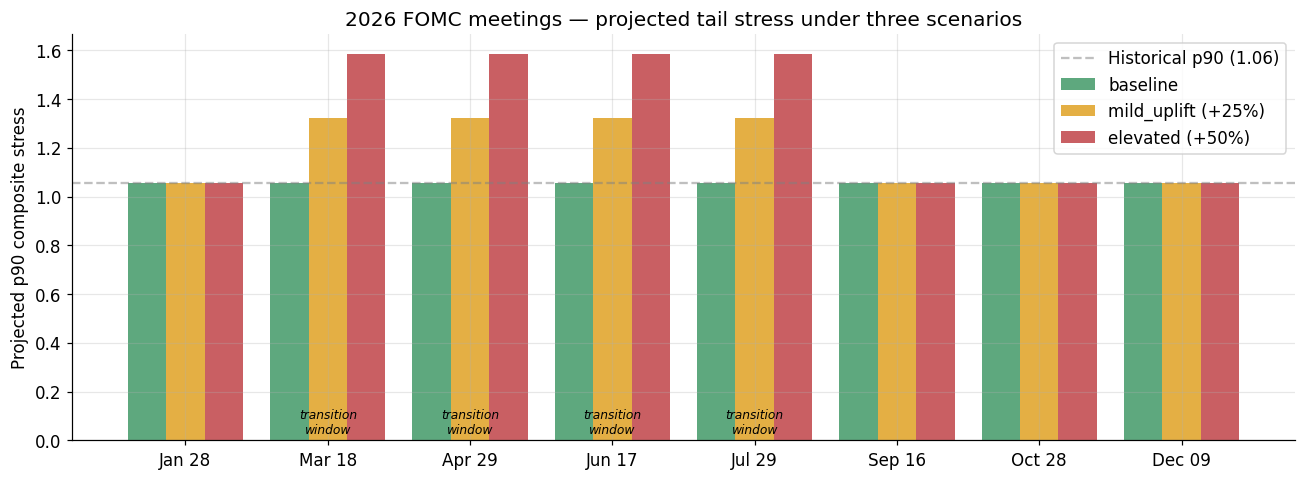


saved: projection_2026_fomc.csv


In [20]:
SCENARIOS = {
    "baseline":           0.00,
    "mild_uplift (+25%)": 0.25,
    "elevated (+50%)":    0.50,
}

projection = fomc26[["meeting_date","days_from_handover","transition_window"]].copy()
for name, uplift in SCENARIOS.items():
    projection[name] = projection["transition_window"].apply(
        lambda inw: unc_p90 * (1 + uplift) if inw else unc_p90
    )

print("PROJECTED p90 STRESS FOR EACH 2026 FOMC MEETING")
print(projection.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(projection))
w = 0.27
colors = ["#4C9F70", "#E1A730", "#C44E52"]
for i, (name, _) in enumerate(SCENARIOS.items()):
    bars = ax.bar(x + (i-1)*w, projection[name], w, label=name, color=colors[i], alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%b %d") for d in projection["meeting_date"]])
ax.axhline(unc_p90, ls="--", color="gray", alpha=0.5, label=f"Historical p90 ({unc_p90:.2f})")
ax.set_ylabel("Projected p90 composite stress")
ax.set_title("2026 FOMC meetings — projected tail stress under three scenarios")
for i, inw in enumerate(projection["transition_window"]):
    if inw:
        ax.text(i, 0.03, "transition\nwindow", ha="center", fontsize=8, color="black", style="italic")
ax.legend(loc="upper right")
plt.tight_layout(); plt.savefig(FIG/"09_2026_fomc_projection.png", bbox_inches="tight"); plt.show()

projection.to_csv("projection_2026_fomc.csv", index=False)
print("\nsaved: projection_2026_fomc.csv")

**What the 2026 projection tells us.**

Under the historical baseline (no transition uplift), every 2026 FOMC carries the same projected p90 of 1.06. The mild scenario (+25%) lifts the transition-window p90 to 1.32. The elevated scenario (+50%) lifts it to 1.59, which approaches historical Crisis-regime FOMC behavior (p90 = 1.95, shown in the regime-conditional table above).

Among the four transition-window meetings, the June 17 meeting is the highest single-date concentration risk because it is the first FOMC after the May 15 handover. After May 2026 has passed, the realized stress at each meeting can be compared against the three projected scenarios to assess which scenario the world actually landed in.

---
### For the writeup and deck

- **Slide 1-2 (data and motivation).** The "improvement we are making" statement from the framing cell, the data inventory table, the 4-panel macro overview, and the fat-tail Q-Q plot establishing why this analysis is needed.

- **Slide 3 (method, regime classification).** The four regime rules (causal expanding-percentile thresholds, minimum-run smoothing) and the shaded VIX timeline showing the classifier passes the eye test on 2008-2009, March 2020, and 2022.

- **Slide 4 (result 1, VRP per regime).** The two-part VRP chart showing how *often* (share) and how *badly* (p95) IV underprices next-month RV, plus the calm-before-the-storm transition diagnostic.

- **Slide 5 (result 2, tails and event analysis).**
  - 5a. Hill α tail-exponent bars per regime, emphasizing the dangerous regimes' fat left tails.
  - 5b. The regime × event-type stress heatmap from Section 6.3, which is the integration finding that justifies the merged framework.

- **Slide 6 (result 3, Virtu validation).** The pre-registered hypothesis verdict table (H2 r=0.46 and H3 r=0.43, both supported with predicted positive sign at the |r| > 0.30 threshold) and the time-series chart of Virtu revenue vs market vol.

- **Slide 7 (conclusion, deliverable and forward application).**
  - The 4 × 5 regime × event risk monitor as the headline deliverable.
  - The 2026 FOMC projection chart highlighting the four transition-window meetings (March 18, April 29, June 17, July 29) around the May 15 Powell handover.

### Limitations to acknowledge

- Credit is measured via Moody's Baa-10Y (ICE OAS is 3yr-capped on FRED). The merged Virtu panel has 49 quarters from 2013-Q4 to 2025-Q4.
- Regime thresholds are causal expanding percentiles with a 3-year warm-up. This is a modelling choice and we state it explicitly.
- Result 1 VRP is forward-looking. The calm-before-the-storm finding is a property of the 21-day horizon, not a contradiction of the thesis.
- Macro level series are date-stamped at the period reference (FRED convention), not release-lagged, so there is mild look-ahead vs actual publication timing in the regime classifier inputs.
- Event surprises are not used in this version. The random-walk surprise series in the data is stamped at FRED period-start dates rather than release dates, making the join error-prone. Bloomberg consensus surprises would be a stronger upgrade if available.
- The 2026 FOMC scenarios are explicitly sensitivity ranges, not predictions. The realized stress at each 2026 meeting can be compared against the projected ranges after the fact.
- The 49-quarter Virtu sample limits Section 7 to correlational, not causal, claims. The framework's 0.43 to 0.46 correlations explain roughly 19% to 21% of Virtu's quarterly net revenue variance, which is meaningful but partial.
- The smallest cell in the Section 6.3 heatmap is Crisis × FOMC with n=7. We flag this in the visualization. The tier assignment for that cell is suggestive rather than statistically precise.
- The composite stress score weights are derived from PCA on the four metrics. We verified the ranking is robust under equal weighting (correlation 0.998 between the two composites).